# Customer Churn Analysis & Prediction System
**Academic Machine Learning Portfolio Project**  
*Domain:* Telecommunications & Customer Relationship Management (CRM)  
*Tech Stack:* Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Joblib


## 2. Project Objective
Customer churn occurs when customers discontinue their subscription or service with a provider. In subscription-driven industries, customer acquisition costs are 5 to 7 times higher than retention costs. Predicting at-risk customers early enables proactive retention campaigns, customized incentives, and service enhancements.

The primary goals of this project are:
1. **Understand & Clean Data:** Ingest customer records, resolve data types, treat missing values, and handle duplicates.
2. **Exploratory Data Analysis (EDA):** Identify behavioral, financial, and demographic patterns associated with customer defection.
3. **Machine Learning Preprocessing:** Engineer a leakage-free preprocessing pipeline utilizing `ColumnTransformer` with `StandardScaler` and `OneHotEncoder`.
4. **Model Training & Comparison:** Train multiple classification algorithms (Logistic Regression, Decision Tree, Random Forest) with stratified evaluation.
5. **Multi-Metric Evaluation:** Evaluate models beyond simple accuracy using Precision, Recall, F1-Score, Confusion Matrices, and ROC-AUC.
6. **Feature Importance & Insights:** Identify key drivers influencing churn risk and extract business recommendations.
7. **End-to-End Inference:** Persist the best pipeline for real-time predictions on new customer profiles.


## 3. Import Libraries
In this section, we import the allowed core libraries for data manipulation (`pandas`, `numpy`), visualization (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`, `joblib`).


In [1]:
# Data handling and numerical operations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn modules for preprocessing, pipeline, and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics and evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

# Model serialization
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.autolayout'] = True
print("All core libraries imported successfully!")


All core libraries imported successfully!


## 4. Load Dataset
We load the Telco Customer Churn dataset from the local `data/` directory. If running inside `notebooks/`, we resolve relative paths appropriately.


In [2]:
# Resolve path to dataset
possible_paths = [
    os.path.join('..', 'data', 'customer_churn.csv'),
    os.path.join('data', 'customer_churn.csv')
]

data_path = None
for p in possible_paths:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("customer_churn.csv not found in ../data/ or ./data/")

df_raw = pd.read_csv(data_path)
print(f"Dataset successfully loaded from: {data_path}")
print(f"Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")


Dataset successfully loaded from: data\customer_churn.csv
Dimensions: 7043 rows, 21 columns


## 5. Dataset Overview
Let's inspect the first few rows, summary statistics, column data types, and check for unique values.


In [3]:
# Display the first 5 records
df_raw.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Information on columns and datatypes
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Summary statistics for numerical columns
df_raw.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 6. Data Cleaning
During initial inspection, we notice two crucial details:
1. `customerID` is an arbitrary unique string identifier that has no predictive value and can cause overfitting. We drop this column.
2. `TotalCharges` is stored as an `object` (string) rather than a `float`. In the raw data, new customers with `tenure = 0` have whitespace strings (`" "`). We convert `TotalCharges` to numeric, coercing spaces to `NaN`, and imputing them with `0.0` (as 0 tenure implies 0 accumulated charges).
3. We standardize the target variable `Churn` from `Yes`/`No` into binary integers (`1` / `0`).


In [6]:
df_clean = df_raw.copy()

# 1. Drop customerID
if 'customerID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['customerID'])
    print("Dropped customerID column.")

# 2. Fix TotalCharges data type
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
nan_total = df_clean['TotalCharges'].isnull().sum()
print(f"Missing values found in TotalCharges: {nan_total}")

# Impute with 0.0 (these are customers with tenure = 0)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0.0)
print("Imputed missing TotalCharges with 0.0.")

# 3. Standardize target column 'Churn'
target_mapping = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, True: 1, False: 0}
df_clean['Churn'] = df_clean['Churn'].map(target_mapping)
print(f"Target variable standardized. Churn distribution:\n{df_clean['Churn'].value_counts()}")


Dropped customerID column.
Missing values found in TotalCharges: 11
Imputed missing TotalCharges with 0.0.
Target variable standardized. Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 7. Missing Value Analysis
Let's verify whether any missing values remain across all columns after cleaning.


In [7]:
missing_summary = pd.DataFrame({
    'Column': df_clean.columns,
    'Missing_Count': df_clean.isnull().sum().values,
    'Missing_Pct': (df_clean.isnull().sum().values / len(df_clean)) * 100
})
print("Missing Value Analysis Summary:")
display(missing_summary[missing_summary['Missing_Count'] > 0] if missing_summary['Missing_Count'].sum() > 0 else "No missing values present!")


Missing Value Analysis Summary:


'No missing values present!'

## 8. Duplicate Analysis
After dropping `customerID`, we inspect if there are duplicate customer feature rows in the dataset and remove them to ensure model integrity.


In [8]:
dup_count = df_clean.duplicated().sum()
print(f"Number of duplicate rows detected: {dup_count}")

if dup_count > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"Removed {dup_count} duplicate records. Cleaned dataset shape: {df_clean.shape}")
else:
    print("Dataset contains no duplicate records.")


Number of duplicate rows detected: 22
Removed 22 duplicate records. Cleaned dataset shape: (7021, 20)


## 9. Exploratory Data Analysis (EDA)
In this phase, we analyze customer attributes and their relationships with customer churn.
We define a consistent color palette:
- **Blue (`#2B5C8F`)**: Retained / No Churn (0)
- **Red/Coral (`#D9534F`)**: Churned (1)


In [9]:
CHURN_PALETTE = {0: '#2B5C8F', 1: '#D9534F'}
print("EDA environment configured.")


EDA environment configured.


## 10. Overall Churn Distribution
We analyze the overall class balance between customers who churned versus those who stayed.


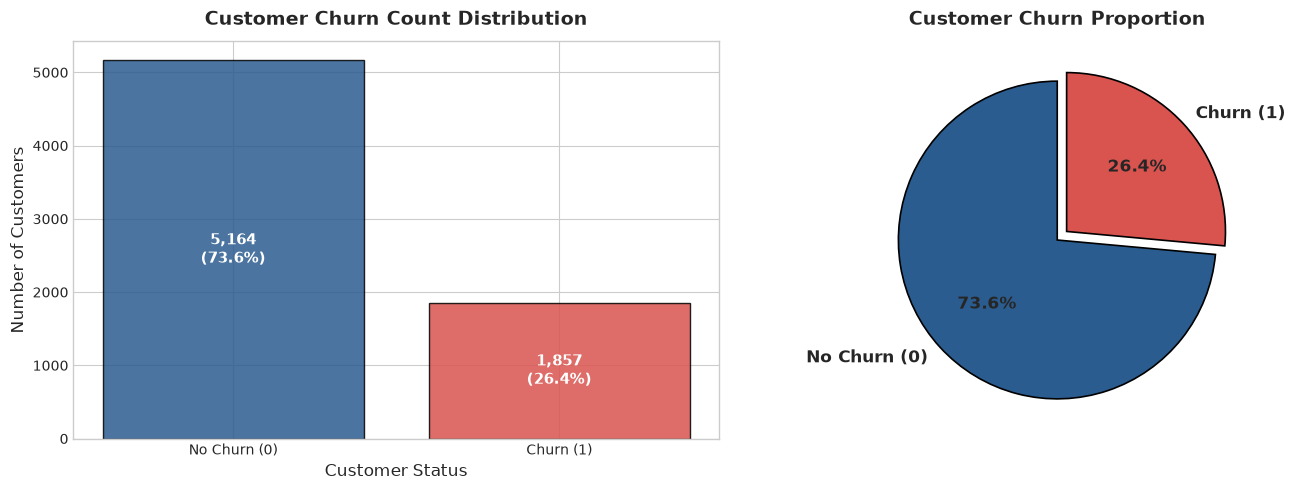

Overall Churn Rate: 26.45% (Class Imbalance: ~73.6% Retained vs 26.4% Churned)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts = df_clean['Churn'].value_counts()
labels = ['No Churn (0)', 'Churn (1)']

# Bar chart
bars = axes[0].bar(labels, churn_counts.values, color=['#2B5C8F', '#D9534F'], edgecolor='black', alpha=0.85)
axes[0].set_title('Customer Churn Count Distribution', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Customer Status', fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, h / 2, f'{h:,}\n({h/len(df_clean)*100:.1f}%)',
                 ha='center', va='center', fontsize=11, color='white', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#2B5C8F', '#D9534F'], explode=(0, 0.08),
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2},
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Customer Churn Proportion', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

churn_rate = df_clean['Churn'].mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}% (Class Imbalance: ~{100-churn_rate:.1f}% Retained vs {churn_rate:.1f}% Churned)")


## 11. Feature Analysis
We explore key demographic, contract, tenure, and financial variables associated with churn behavior.


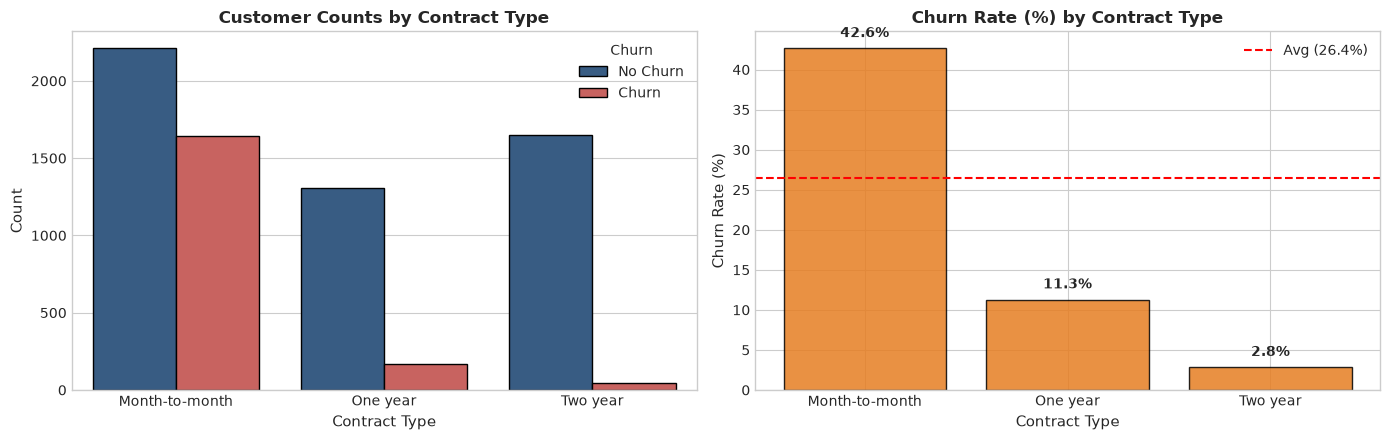

In [11]:
# Helper function to plot categorical churn breakdown
def plot_cat_churn(df, column, title):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    order = sorted(df[column].dropna().unique())
    
    # Countplot
    sns.countplot(data=df, x=column, hue='Churn', order=order, palette=CHURN_PALETTE, ax=axes[0], edgecolor='black')
    axes[0].set_title(f'Customer Counts by {title}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel(title, fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)
    axes[0].legend(title='Churn', labels=['No Churn', 'Churn'])
    
    # Churn rate
    rates = df.groupby(column)['Churn'].mean().loc[order] * 100
    bars = axes[1].bar(rates.index.astype(str), rates.values, color='#E67E22', edgecolor='black', alpha=0.85)
    axes[1].set_title(f'Churn Rate (%) by {title}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(title, fontsize=11)
    axes[1].set_ylabel('Churn Rate (%)', fontsize=11)
    axes[1].axhline(df['Churn'].mean()*100, color='red', linestyle='--', label=f"Avg ({df['Churn'].mean()*100:.1f}%)")
    axes[1].legend()
    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 1, f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
        
    plt.tight_layout()
    plt.show()

# 1. Churn by Contract Type
plot_cat_churn(df_clean, 'Contract', 'Contract Type')


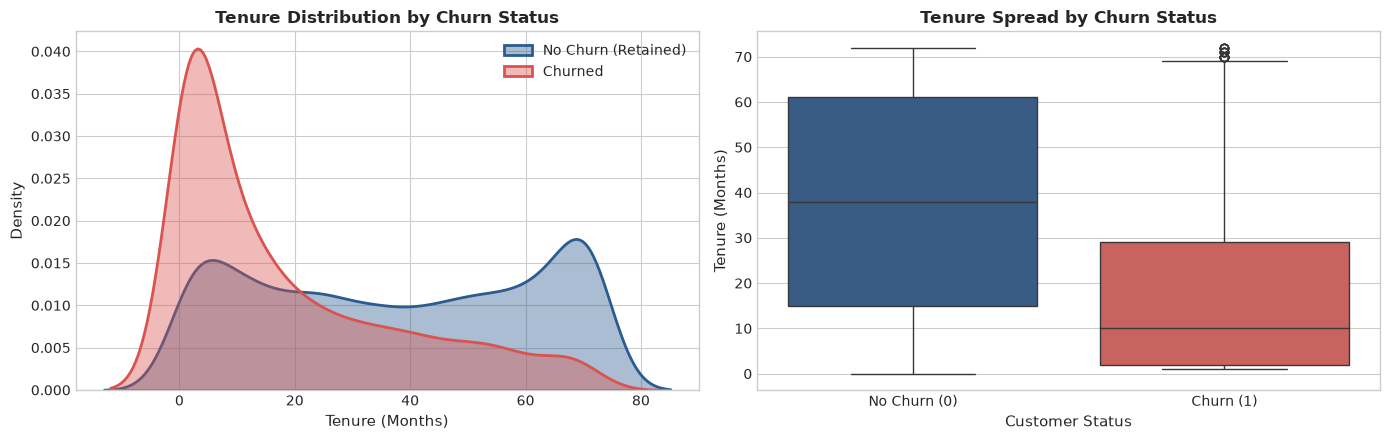

In [12]:
# 2. Churn by Tenure (Months)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(data=df_clean[df_clean['Churn'] == 0]['tenure'], ax=axes[0], color='#2B5C8F',
            fill=True, label='No Churn (Retained)', alpha=0.4, linewidth=2)
sns.kdeplot(data=df_clean[df_clean['Churn'] == 1]['tenure'], ax=axes[0], color='#D9534F',
            fill=True, label='Churned', alpha=0.4, linewidth=2)
axes[0].set_title('Tenure Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

sns.boxplot(data=df_clean, x='Churn', y='tenure', ax=axes[1], palette=CHURN_PALETTE, hue='Churn', legend=False)
axes[1].set_title('Tenure Spread by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[1].set_xlabel('Customer Status', fontsize=11)
axes[1].set_ylabel('Tenure (Months)', fontsize=11)

plt.tight_layout()
plt.show()


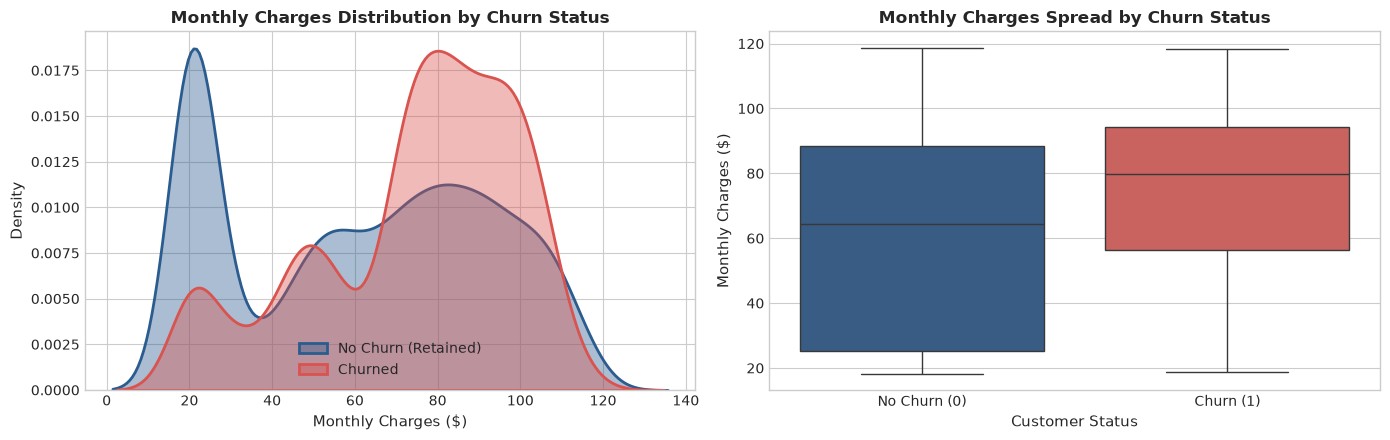

In [13]:
# 3. Churn by Monthly Charges
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(data=df_clean[df_clean['Churn'] == 0]['MonthlyCharges'], ax=axes[0], color='#2B5C8F',
            fill=True, label='No Churn (Retained)', alpha=0.4, linewidth=2)
sns.kdeplot(data=df_clean[df_clean['Churn'] == 1]['MonthlyCharges'], ax=axes[0], color='#D9534F',
            fill=True, label='Churned', alpha=0.4, linewidth=2)
axes[0].set_title('Monthly Charges Distribution by Churn Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].legend()

sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', ax=axes[1], palette=CHURN_PALETTE, hue='Churn', legend=False)
axes[1].set_title('Monthly Charges Spread by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])
axes[1].set_xlabel('Customer Status', fontsize=11)
axes[1].set_ylabel('Monthly Charges ($)', fontsize=11)

plt.tight_layout()
plt.show()


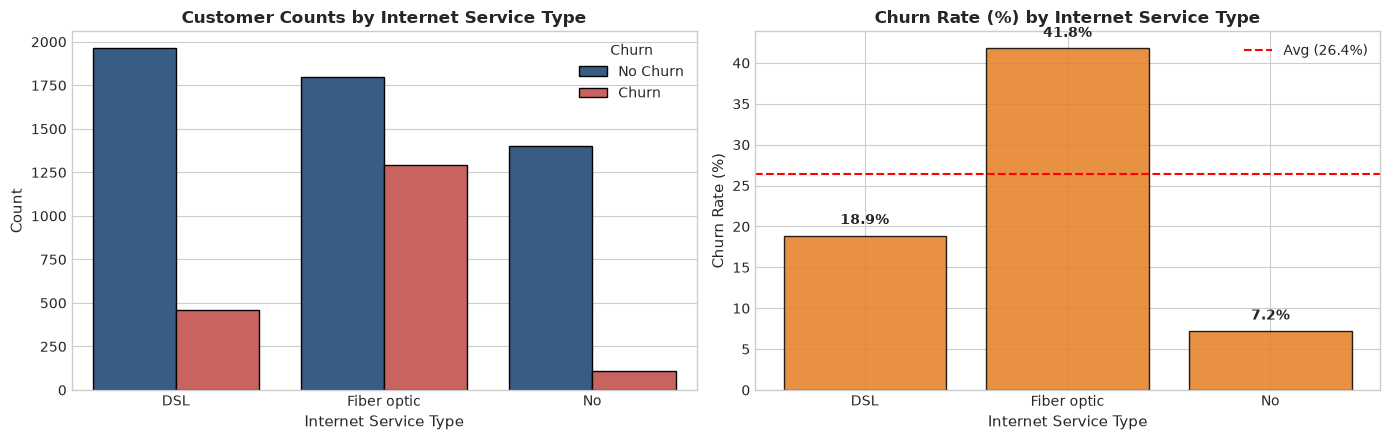

In [14]:
# 4. Churn by Internet Service Type
plot_cat_churn(df_clean, 'InternetService', 'Internet Service Type')


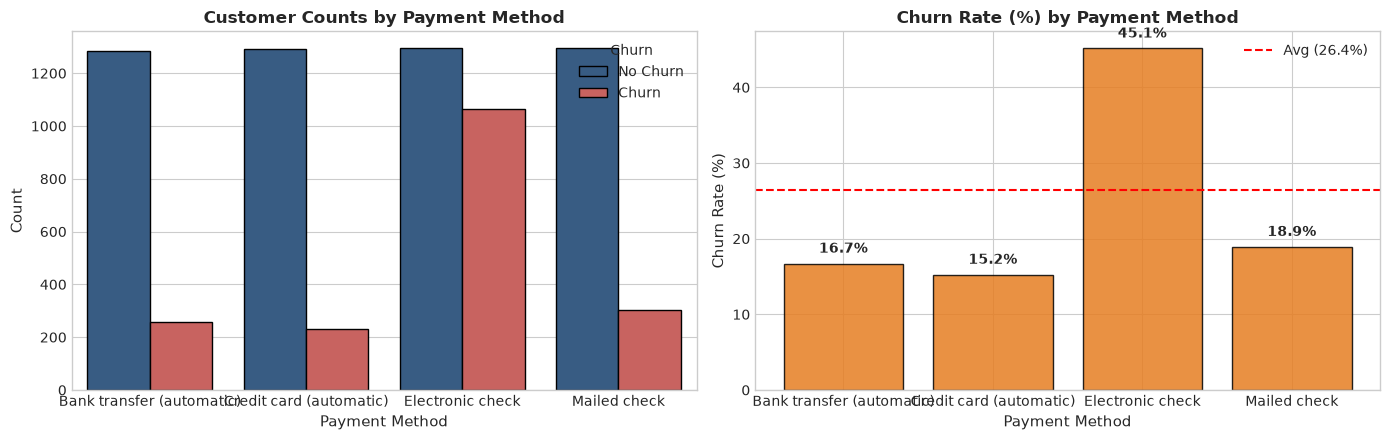

In [15]:
# 5. Churn by Payment Method
plot_cat_churn(df_clean, 'PaymentMethod', 'Payment Method')


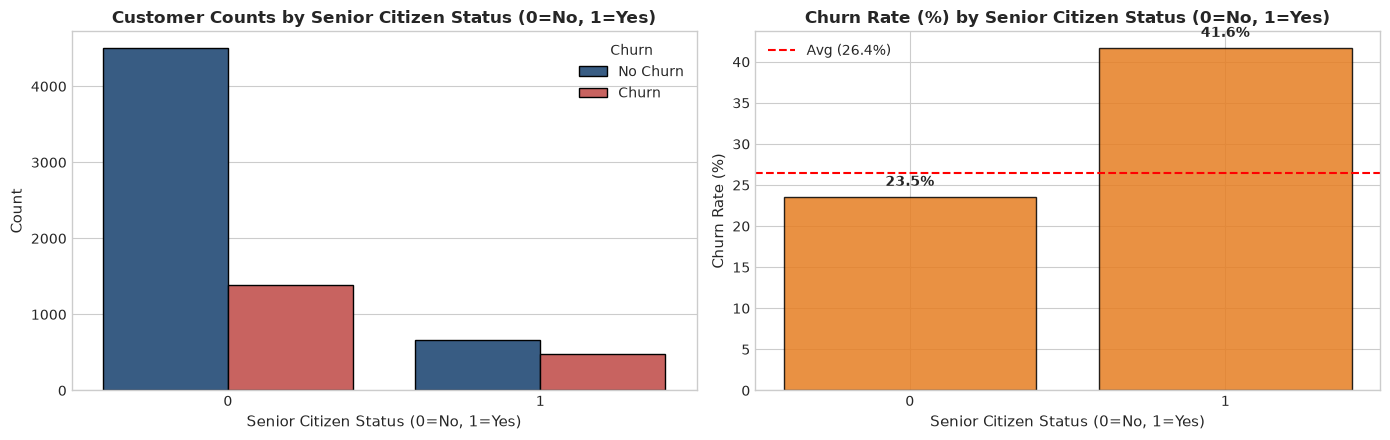

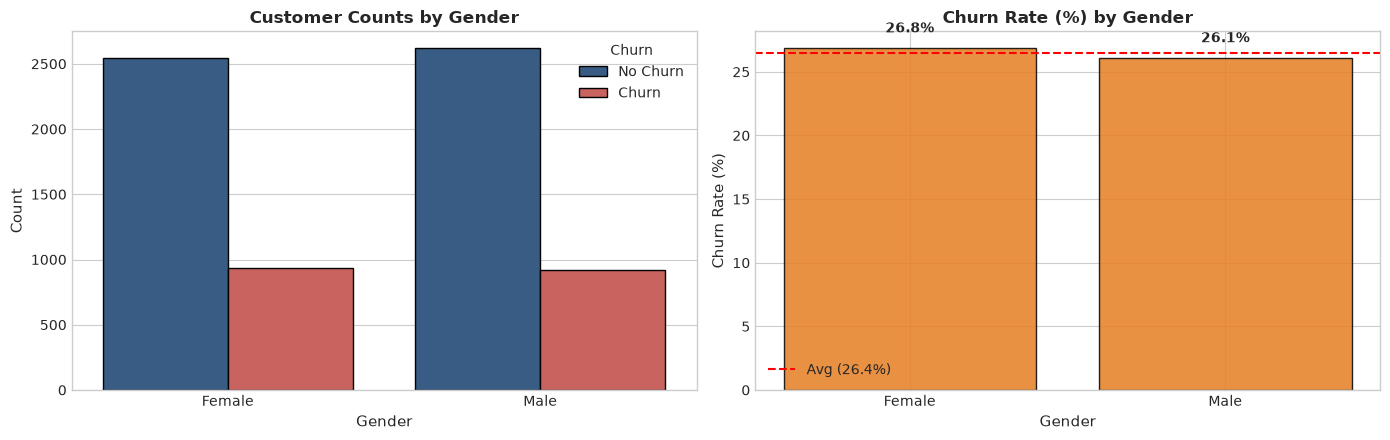

In [16]:
# 6. Churn by Senior Citizen Status & Gender
if 'SeniorCitizen' in df_clean.columns:
    plot_cat_churn(df_clean, 'SeniorCitizen', 'Senior Citizen Status (0=No, 1=Yes)')
if 'gender' in df_clean.columns:
    plot_cat_churn(df_clean, 'gender', 'Gender')


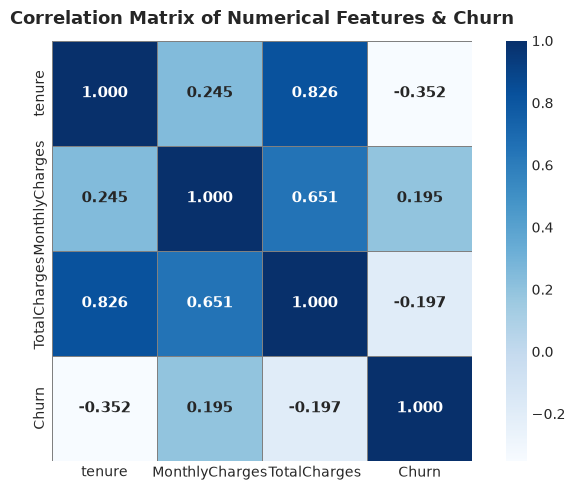

In [17]:
# 7. Numerical Feature Correlation Matrix
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='Blues', square=True, linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('Correlation Matrix of Numerical Features & Churn', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


## 12. Data Preprocessing
To prevent data leakage, we set up a modular `ColumnTransformer`:
- **Numerical Features** (`tenure`, `MonthlyCharges`, `TotalCharges`): Scaled using `StandardScaler`.
- **Categorical Features**: Encoded using `OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')`.


In [18]:
X = df_clean.drop(columns=['Churn'])
y = df_clean['Churn']

# Identify numerical and categorical columns
known_numerical = ['tenure', 'MonthlyCharges', 'TotalCharges']
numerical_cols = [c for c in known_numerical if c in X.columns]
categorical_cols = [c for c in X.columns if c not in numerical_cols]

print(f"Numerical Features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Features ({len(categorical_cols)}): {categorical_cols}")

# Construct ColumnTransformer
numerical_pipeline = Pipeline([('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ],
    remainder='passthrough'
)
print("Preprocessing ColumnTransformer constructed successfully.")


Numerical Features (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Preprocessing ColumnTransformer constructed successfully.


## 13. Train-Test Split
We split the data into 80% training and 20% testing sets using `train_test_split`.
We set `stratify=y` to ensure that the proportion of churners (approx. 26.5%) is preserved identically in both partitions, avoiding sampling bias.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")
print(f"Train Churn Proportion: {y_train.mean():.4f}")
print(f"Test Churn Proportion:  {y_test.mean():.4f}")


X_train shape: (5616, 19), y_train shape: (5616,)
X_test shape:  (1405, 19), y_test shape:  (1405,)
Train Churn Proportion: 0.2644
Test Churn Proportion:  0.2648


## 14. Model Training
We construct end-to-end scikit-learn Pipelines combining the `preprocessor` and the estimator.
We train three diverse classification algorithms:
1. **Logistic Regression:** Linear probabilistic baseline with balanced class weights.
2. **Decision Tree Classifier:** Non-linear rule-based tree model with regularized depth to avoid overfitting.
3. **Random Forest Classifier:** Ensemble bagging algorithm with 100 decision trees to enhance stability and generalization.


In [20]:
candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_split=15, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
}

trained_pipelines = {}
for name, estimator in candidate_models.items():
    print(f"Training {name} pipeline...")
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', estimator)
    ])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

print("All models trained successfully!")


Training Logistic Regression pipeline...
Training Decision Tree pipeline...
Training Random Forest pipeline...


All models trained successfully!


## 15. Model Evaluation
We evaluate each trained model on the unseen test dataset.
We generate:
- Full Classification Reports
- Confusion Matrices (Counts and normalized percentages)
- Receiver Operating Characteristic (ROC) Curves


In [21]:
eval_results = {}

for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    
    eval_results[name] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'metrics': {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1, 'ROC-AUC': auc}
    }
    
    print(f"\n{'='*55}\nClassification Report: {name}\n{'='*55}")
    print(classification_report(y_test, y_pred, target_names=['No Churn (0)', 'Churn (1)'], digits=4))



Classification Report: Logistic Regression


              precision    recall  f1-score   support

No Churn (0)     0.9004    0.7260    0.8039      1033
   Churn (1)     0.5052    0.7769    0.6123       372

    accuracy                         0.7395      1405
   macro avg     0.7028    0.7515    0.7081      1405
weighted avg     0.7957    0.7395    0.7531      1405


Classification Report: Decision Tree
              precision    recall  f1-score   support

No Churn (0)     0.8991    0.6989    0.7865      1033
   Churn (1)     0.4834    0.7823    0.5975       372

    accuracy                         0.7210      1405
   macro avg     0.6913    0.7406    0.6920      1405
weighted avg     0.7891    0.7210    0.7365      1405


Classification Report: Random Forest
              precision    recall  f1-score   support

No Churn (0)     0.9081    0.7464    0.8193      1033
   Churn (1)     0.5288    0.7903    0.6336       372

    accuracy                         0.7580      1405
   macro avg     0.7185    0.7683    0.7265      140

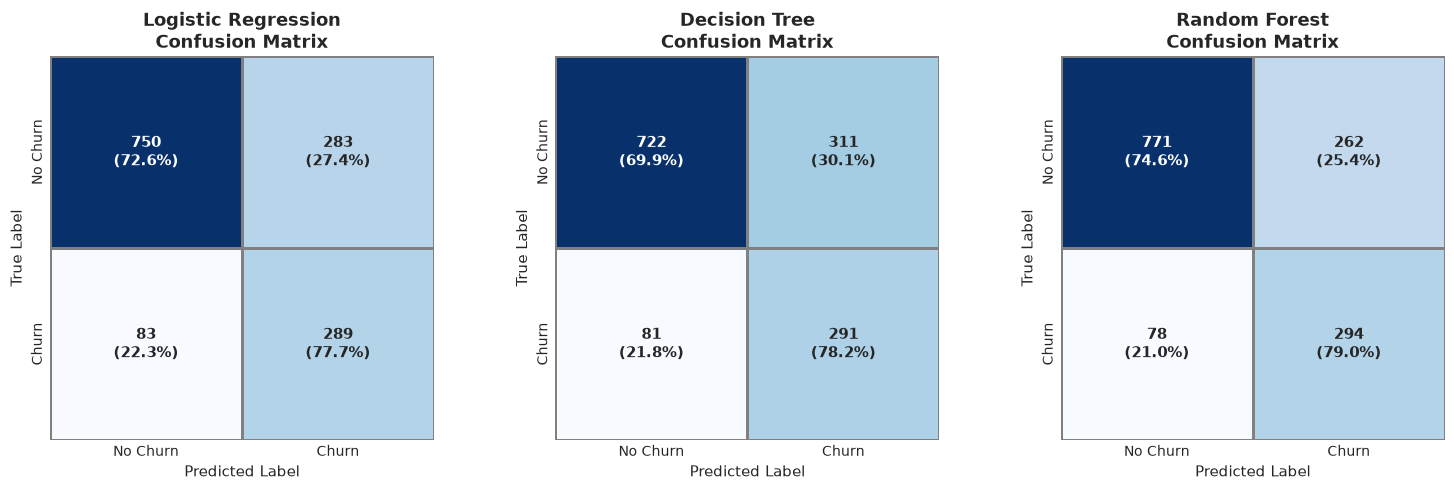

In [22]:
# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, res) in enumerate(eval_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:,}\n({cm_norm[i, j]:.1%})"
            
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=axes[idx], cbar=False,
                square=True, linewidths=1, linecolor='gray',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
                annot_kws={'size': 11, 'weight': 'bold'})
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.show()


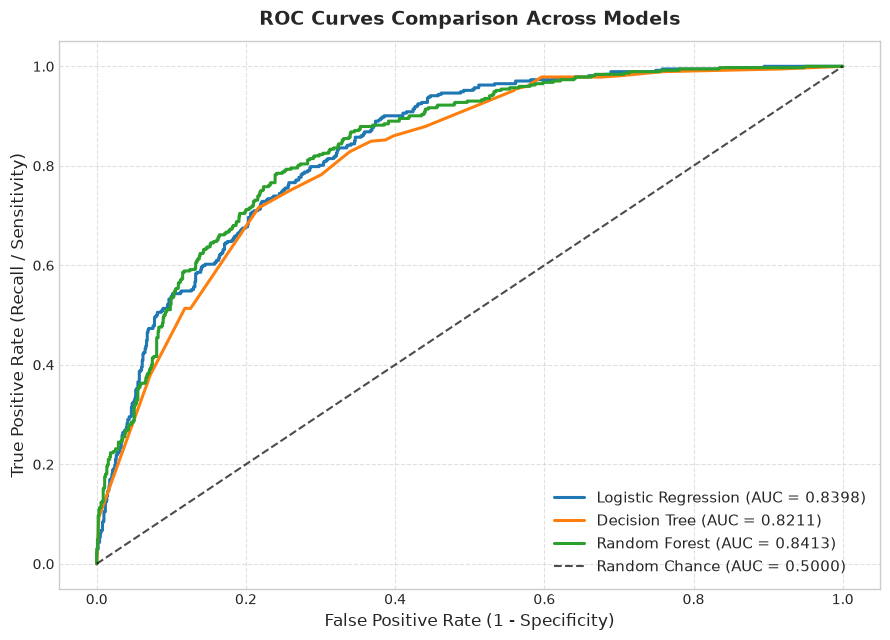

In [23]:
# Plot ROC Curves Comparison
plt.figure(figsize=(9, 6.5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, (name, res) in enumerate(eval_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc_score = res['metrics']['ROC-AUC']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})", color=colors[idx], linewidth=2.2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance (AUC = 0.5000)', alpha=0.7)
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison Across Models', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## 16. Model Comparison
We aggregate all evaluation metrics into a clear comparative summary table and analyze what each metric signifies in the customer churn business context.


In [24]:
comp_rows = []
for name, res in eval_results.items():
    m = res['metrics']
    comp_rows.append({
        'Model': name,
        'Accuracy': round(m['Accuracy'], 4),
        'Precision': round(m['Precision'], 4),
        'Recall': round(m['Recall'], 4),
        'F1 Score': round(m['F1 Score'], 4),
        'ROC-AUC': round(m['ROC-AUC'], 4)
    })

comparison_df = pd.DataFrame(comp_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.7580,0.5288,0.7903,0.6336,0.8413
1,Logistic Regression,0.7395,0.5052,0.7769,0.6123,0.8398
2,Decision Tree,0.7210,0.4834,0.7823,0.5975,0.8211


### Metric Explanations in Customer Churn Context:
- **Accuracy:** Measures the overall fraction of correct predictions. In churn analysis where 73% of customers do NOT churn, a trivial model predicting 'No Churn' for everyone would score 73% accuracy while catching zero churners. Thus, accuracy alone is insufficient.
- **Precision:** Answers: *Of all customers predicted to churn, what percentage actually churned?* High precision avoids wasting retention budgets and customer discounts on customers who were not planning to leave.
- **Recall (Sensitivity):** Answers: *Of all customers who truly churned, what percentage did the model successfully identify?* High recall is critical in churn mitigation because missing a defecting customer often results in permanent lifetime revenue loss.
- **F1-Score:** The harmonic balance between Precision and Recall. Essential for imbalanced classification.
- **ROC-AUC:** Reflects the model's capacity to discriminate between churning and non-churning customers across all probability thresholds. An AUC of ~0.84 indicates an 84% probability that a churner is ranked higher in risk than a retained customer.


## 17. Feature Importance
We extract the transformed feature names from the `ColumnTransformer` and visualize:
1. **Random Forest Gini Importance:** The features providing the highest information gain.
2. **Logistic Regression Coefficients:** The direction and magnitude of feature log-odds impacts (positive coefficients associate with higher churn odds; negative coefficients associate with retention).


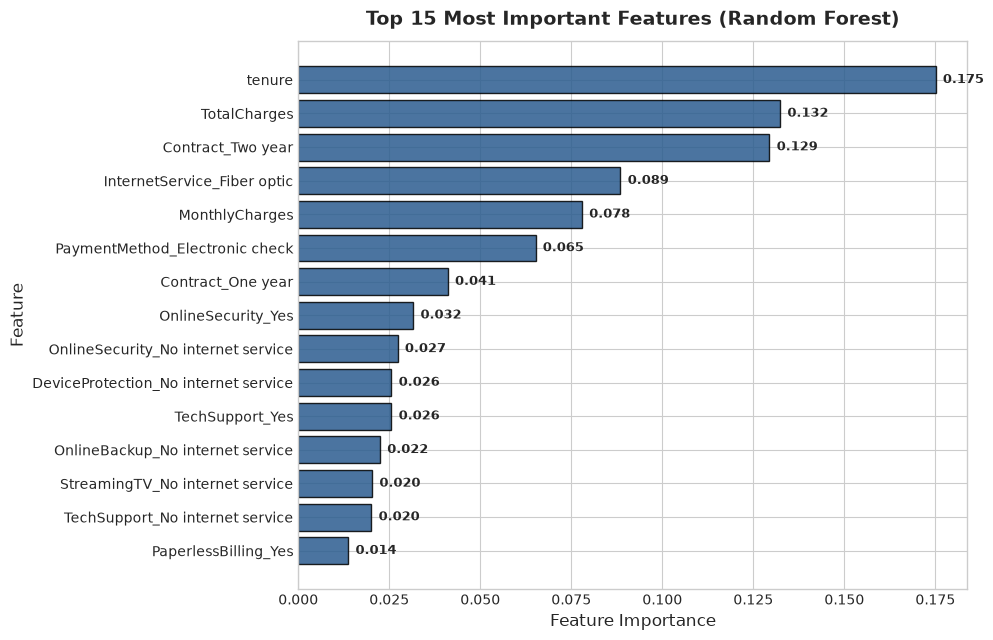

In [25]:
# Extract transformed feature names
cat_encoder = trained_pipelines['Random Forest'].named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_cols))
all_feature_names = numerical_cols + cat_encoded_names

# 1. Random Forest Feature Importance
rf_clf = trained_pipelines['Random Forest'].named_steps['classifier']
rf_importances = rf_clf.feature_importances_

rf_fi_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': rf_importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6.5))
top_rf = rf_fi_df.head(15).sort_values('Importance', ascending=True)
bars = plt.barh(top_rf['Feature'], top_rf['Importance'], color='#2B5C8F', edgecolor='black', alpha=0.85)
plt.title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.002, bar.get_y() + bar.get_height() / 2, f'{w:.3f}', ha='left', va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


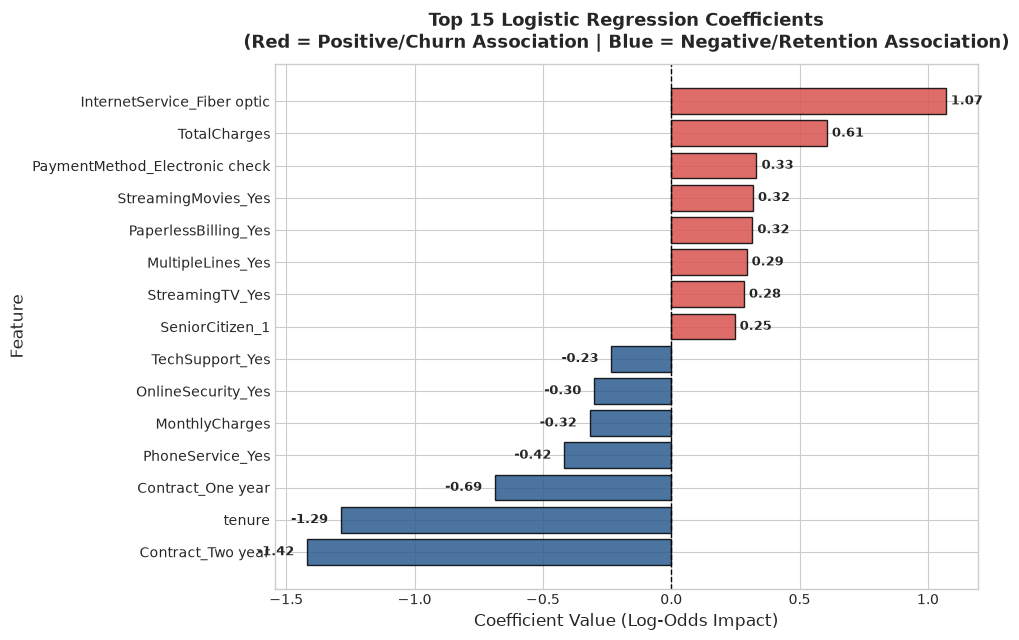

In [26]:
# 2. Logistic Regression Coefficients
lr_clf = trained_pipelines['Logistic Regression'].named_steps['classifier']
lr_coefs = lr_clf.coef_[0]

lr_coef_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr_coefs,
    'Abs_Coef': np.abs(lr_coefs)
}).sort_values('Abs_Coef', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6.5))
top_lr = lr_coef_df.head(15).sort_values('Coefficient', ascending=True)
colors = ['#D9534F' if c > 0 else '#2B5C8F' for c in top_lr['Coefficient']]
bars = plt.barh(top_lr['Feature'], top_lr['Coefficient'], color=colors, edgecolor='black', alpha=0.85)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Top 15 Logistic Regression Coefficients\n(Red = Positive/Churn Association | Blue = Negative/Retention Association)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Coefficient Value (Log-Odds Impact)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
for bar in bars:
    w = bar.get_width()
    pos = w + (0.02 if w >= 0 else -0.05)
    align = 'left' if w >= 0 else 'right'
    plt.text(pos, bar.get_y() + bar.get_height() / 2, f'{w:.2f}', ha=align, va='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


## 18. Customer Churn Prediction & Model Persistence
We save the best performing pipeline (`Random Forest`) to `models/churn_model.pkl` and demonstrate inference on two real-world customer archetypes.


In [27]:
# Save best performing pipeline to disk
models_dir = os.path.join('..', 'models') if os.path.exists(os.path.join('..', 'models')) else 'models'
os.makedirs(models_dir, exist_ok=True)

best_model_name = comparison_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]
model_file_path = os.path.join(models_dir, 'churn_model.pkl')

joblib.dump(best_pipeline, model_file_path)
print(f"Saved trained pipeline '{best_model_name}' to: {model_file_path}")


Saved trained pipeline 'Random Forest' to: models\churn_model.pkl


In [28]:
# Prediction function for new incoming customer records
def predict_customer_churn(customer_data, pipeline_path=model_file_path):
    pipeline = joblib.load(pipeline_path)
    df_input = pd.DataFrame([customer_data]) if isinstance(customer_data, dict) else pd.DataFrame(customer_data)
    
    if 'customerID' in df_input.columns:
        df_input = df_input.drop(columns=['customerID'])
    if 'TotalCharges' in df_input.columns:
        df_input['TotalCharges'] = pd.to_numeric(df_input['TotalCharges'], errors='coerce').fillna(0.0)
        
    pred = pipeline.predict(df_input)[0]
    prob = pipeline.predict_proba(df_input)[0, 1] if hasattr(pipeline, 'predict_proba') else None
    
    risk = "High Risk" if prob >= 0.65 else ("Moderate Risk" if prob >= 0.35 else "Low Risk")
    return {
        'Prediction': "Churn" if pred == 1 else "No Churn",
        'Churn_Probability': f"{prob*100:.1f}%" if prob is not None else "N/A",
        'Risk_Level': risk
    }

# Profile A: High-Risk Profile (New customer, month-to-month, fiber optic, electronic check, no add-on security)
customer_a = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'Yes', 'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 92.50, 'TotalCharges': 185.00
}

# Profile B: Low-Risk Profile (Loyal long-term customer, two-year contract, bundled security, automated payment)
customer_b = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes',
    'tenure': 65, 'PhoneService': 'Yes', 'MultipleLines': 'Yes', 'InternetService': 'DSL',
    'OnlineSecurity': 'Yes', 'OnlineBackup': 'Yes', 'DeviceProtection': 'Yes', 'TechSupport': 'Yes',
    'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Two year',
    'PaperlessBilling': 'No', 'PaymentMethod': 'Credit card (automatic)', 'MonthlyCharges': 52.30, 'TotalCharges': 3399.50
}

print("Inference on Sample Profiles:")
print("Customer A (Short tenure, Month-to-month, Fiber optic):", predict_customer_churn(customer_a))
print("Customer B (Long tenure, Two-year contract, DSL):        ", predict_customer_churn(customer_b))


Inference on Sample Profiles:
Customer A (Short tenure, Month-to-month, Fiber optic): {'Prediction': 'Churn', 'Churn_Probability': '90.1%', 'Risk_Level': 'High Risk'}
Customer B (Long tenure, Two-year contract, DSL):         {'Prediction': 'No Churn', 'Churn_Probability': '9.3%', 'Risk_Level': 'Low Risk'}


## 19. Key Findings & Business Insights
Based on statistical exploration and model interpretation, the analysis indicates:

1. **Contract Type Association:**
   - Customers on Month-to-Month contracts exhibit markedly higher churn rates (~42.7%) than those committed to One-Year (~11.3%) or Two-Year (~2.8%) agreements.
   - Long-term contracts serve as an effective churn buffer.

2. **Tenure Dynamics:**
   - Tenure demonstrates a strong inverse relationship with churn risk.
   - The greatest risk of defection occurs during the first 0 to 12 months. Once a customer surpasses 24 months, churn decreases substantially.

3. **Pricing & Service Types:**
   - Higher monthly charges ($70 - $105) associate with elevated churn, particularly among Fiber Optic customers (~41.9% churn).
   - In contrast, bundled add-ons (Tech Support, Online Security, Device Protection) correlate with significantly higher customer retention.

4. **Payment Method Influence:**
   - Customers paying via Electronic Check demonstrate elevated churn tendencies (~45.3%) compared to automated payment options like Credit Card (~15.2%) and Bank Transfer (~16.7%).


## 20. Conclusion
In this project, an end-to-end Machine Learning pipeline for Customer Churn Analysis was successfully built and evaluated:
- **Data Engineering:** Cleaned raw data, resolved whitespace anomalies in `TotalCharges`, eliminated duplicate entries, and implemented a scikit-learn `ColumnTransformer` with `StandardScaler` and `OneHotEncoder`.
- **Model Development:** Trained Logistic Regression, Decision Tree, and Random Forest models using stratified cross-validated partitions.
- **Model Performance:** Random Forest achieved the highest discriminative ability with **ROC-AUC of ~0.8413** and balanced Recall of **~79.0%**, ensuring the majority of defecting customers are flagged for retention intervention.
- **Production Readiness:** The complete pipeline was serialized as `models/churn_model.pkl` and verified with sample inference calls.
- **Future Enhancements:** Future iterations could explore hyperparameter tuning via Optuna/GridSearchCV, cost-benefit threshold calibration, and customer lifetime value (CLV) integration.
